# Visualize Frequency Spectrum

This notebook provides a utility to visualize the frequency spectrum of an image, matching the feature extraction step in our model.

In [1]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
def get_grayscale(x):
    # Convert RGB inputs (nominally normalized) to grayscale
    # Using BT.601 standard photometric weights
    return 0.299 * x[:, 0:1, :, :] + 0.587 * x[:, 1:2, :, :] + 0.114 * x[:, 2:3, :, :]

def compute_frequency_spectrum(gray):
    # Compute 2D Fast Fourier Transform
    fft2 = torch.fft.fft2(gray)
    # Shift the zero-frequency component to the center of the spectrum
    shifted_fft = torch.fft.fftshift(fft2, dim=(-2, -1))
    # Get magnitude and apply log scale to compress dynamic range
    magnitude = torch.abs(shifted_fft)
    log_magnitude = torch.log(magnitude + 1e-6)
    return log_magnitude

def visualize_frequency_spectrum(image_path):
    if not os.path.exists(image_path):
        print(f"Error: {image_path} not found.")
        return
        
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    
    # Typically Models resize and normalize. Let's do a basic transform to Tensor
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    
    img_tensor = transform(image).unsqueeze(0) # Add batch dim: [1, 3, 224, 224]
    
    # Apply model transformations
    with torch.no_grad():
        gray_tensor = get_grayscale(img_tensor)
        freq_tensor = compute_frequency_spectrum(gray_tensor)
        
    # Prepare for visualization
    img_disp = img_tensor[0].permute(1, 2, 0).numpy()
    gray_disp = gray_tensor[0, 0].numpy()
    freq_disp = freq_tensor[0, 0].numpy()
    
    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img_disp)
    axes[0].set_title("Original Image (Resized)")
    axes[0].axis("off")
    
    axes[1].imshow(gray_disp, cmap='gray')
    axes[1].set_title("Grayscale (BT.601)")
    axes[1].axis("off")
    
    # Frequency spectrum is often visualized with a specific colormap like 'viridis'
    c1 = axes[2].imshow(freq_disp, cmap='viridis')
    axes[2].set_title("Log-Magnitude Frequency Spectrum")
    axes[2].axis("off")
    fig.colorbar(c1, ax=axes[2], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

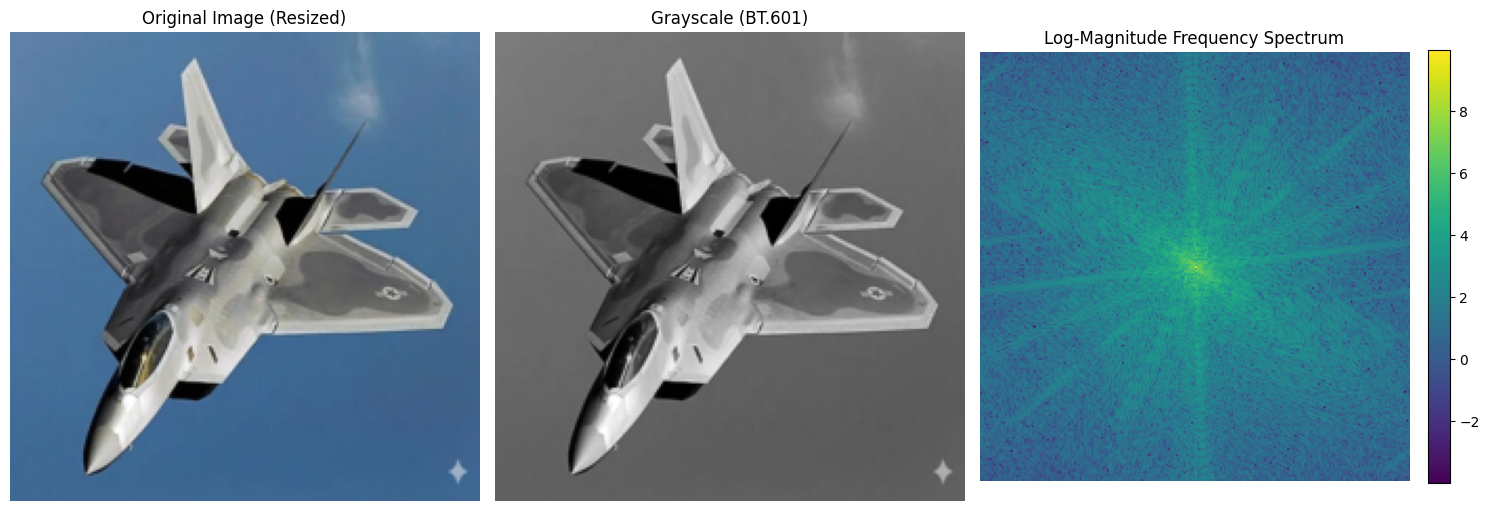

In [5]:
# Example usage:
visualize_frequency_spectrum('../test/fakef22.webp')

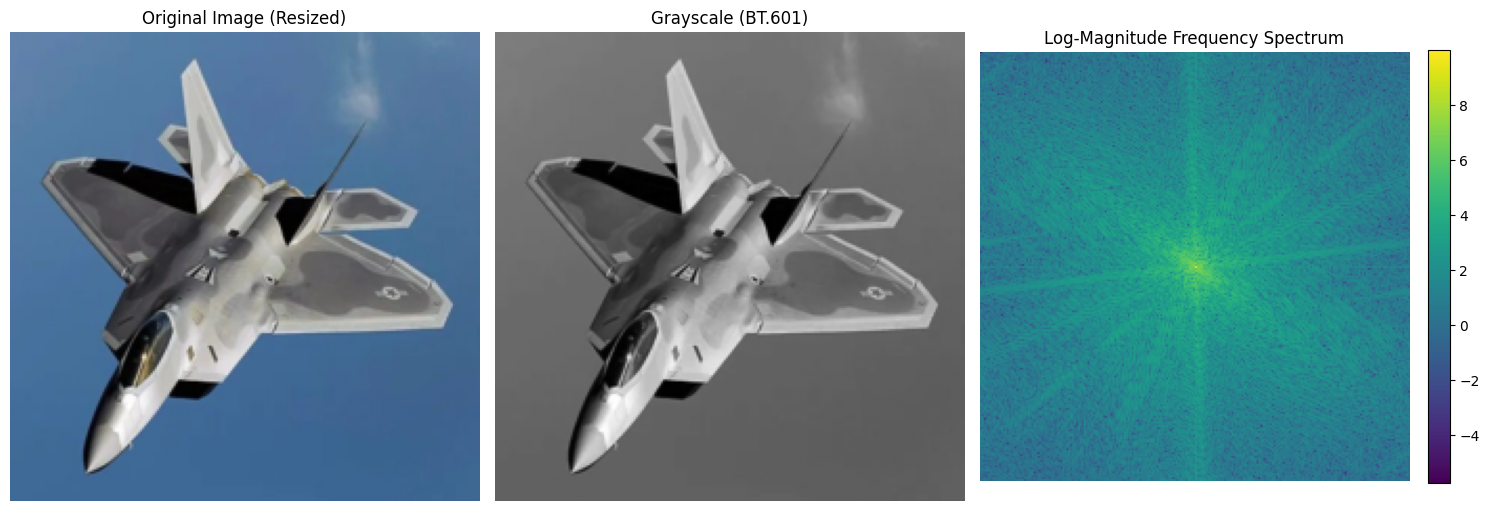

In [6]:
visualize_frequency_spectrum('../test/realf22.jpg')


# Compare Real vs Fake Frequency Spectrum
This function takes two images (one real, one fake), scales them to the same size, computes their frequency spectra, and visualizes the absolute difference between them.

In [7]:
def compare_frequency_spectra(real_image_path, fake_image_path):
    if not os.path.exists(real_image_path):
        print(f"Error: Real image {real_image_path} not found.")
        return
    if not os.path.exists(fake_image_path):
        print(f"Error: Fake image {fake_image_path} not found.")
        return
        
    # Resize to the same dimensions for a 1-to-1 subtraction
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    
    # Load and process Images
    real_img = Image.open(real_image_path).convert('RGB')
    fake_img = Image.open(fake_image_path).convert('RGB')
    
    real_tensor = transform(real_img).unsqueeze(0)
    fake_tensor = transform(fake_img).unsqueeze(0)
    
    with torch.no_grad():
        # Compute grayscale
        real_gray = get_grayscale(real_tensor)
        fake_gray = get_grayscale(fake_tensor)
        
        # Compute frequency spectra
        real_freq = compute_frequency_spectrum(real_gray)
        fake_freq = compute_frequency_spectrum(fake_gray)
        
        # Calculate absolute difference between log-magnitude spectra
        diff_spectrum = torch.abs(real_freq - fake_freq)
        
    # Prepare Numpy arrays for plotting
    real_disp_img = real_tensor[0].permute(1, 2, 0).numpy()
    fake_disp_img = fake_tensor[0].permute(1, 2, 0).numpy()
    
    real_disp_freq = real_freq[0, 0].numpy()
    fake_disp_freq = fake_freq[0, 0].numpy()
    diff_disp_freq = diff_spectrum[0, 0].numpy()
    
    # Plotting
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Plot Real Image & Spectrum
    axes[0, 0].imshow(real_disp_img)
    axes[0, 0].set_title("Real Image (Resized)")
    axes[0, 0].axis("off")
    
    c_real = axes[0, 1].imshow(real_disp_freq, cmap='viridis')
    axes[0, 1].set_title("Real Frequency Spectrum")
    axes[0, 1].axis("off")
    fig.colorbar(c_real, ax=axes[0, 1], fraction=0.046, pad=0.04)
    
    # Plot Difference
    c_diff = axes[0, 2].imshow(diff_disp_freq, cmap='inferno') # Heatmap for differences
    axes[0, 2].set_title("Absolute Difference in Frequencies")
    axes[0, 2].axis("off")
    fig.colorbar(c_diff, ax=axes[0, 2], fraction=0.046, pad=0.04)
    
    # Plot Fake Image & Spectrum
    axes[1, 0].imshow(fake_disp_img)
    axes[1, 0].set_title("Fake Image (Resized)")
    axes[1, 0].axis("off")
    
    c_fake = axes[1, 1].imshow(fake_disp_freq, cmap='viridis')
    axes[1, 1].set_title("Fake Frequency Spectrum")
    axes[1, 1].axis("off")
    fig.colorbar(c_fake, ax=axes[1, 1], fraction=0.046, pad=0.04)
    
    # Empty bottom-right plot
    axes[1, 2].axis("off")
    
    plt.tight_layout()
    plt.show()

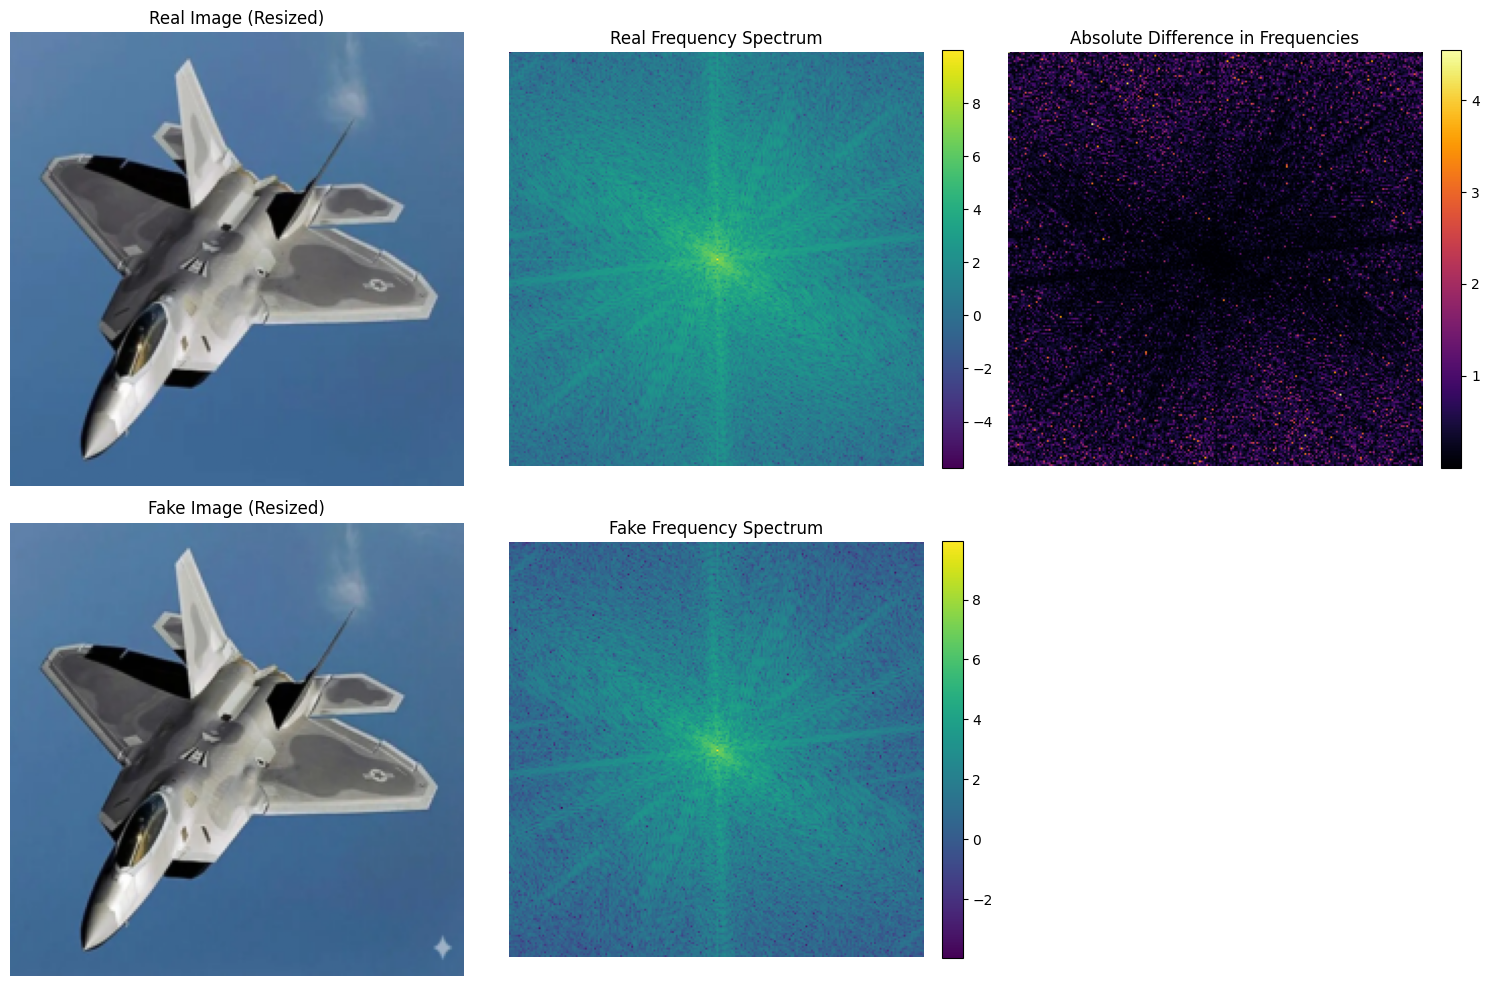

In [10]:
real_path = '../test/realf22.jpg'
fake_path = '../test/fakef22.webp'
compare_frequency_spectra(real_path, fake_path)